In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv('student_performance.csv')
df

,student_id,gender,age,study_hours_per_week,attendance_rate,parent_education,internet_access,extracurricular,previous_score,final_score,passed
0,STU0001,Male,15,25,63.8,Bachelor,Yes,Yes,41,67,Yes
1,STU0002,Female,15,2,54.7,Bachelor,Yes,Yes,83,28,No
2,STU0003,Female,19,10,90.5,High School,Yes,No,73,49,No
3,STU0004,Male,16,26,66.8,High School,No,Yes,75,70,Yes
4,STU0005,Female,15,25,73.0,High School,No,Yes,67,77,Yes
...,...,...,...,...,...,...,...,...,...,...,...
495,STU0496,Female,19,6,78.3,Master,No,No,51,27,No
496,STU0497,Female,16,27,61.1,PhD,No,No,47,74,Yes
497,STU0498,Female,18,16,72.3,Master,No,Yes,52,61,Yes
498,STU0499,Male,17,29,91.3,NaN,Yes,No,39,86,Yes


In [4]:
df = df[['study_hours_per_week','attendance_rate','passed']]
df

,study_hours_per_week,attendance_rate,passed
0,25,63.8,Yes
1,2,54.7,No
2,10,90.5,No
3,26,66.8,Yes
4,25,73.0,Yes
...,...,...,...
495,6,78.3,No
496,27,61.1,Yes
497,16,72.3,Yes
498,29,91.3,Yes


<Axes: xlabel='study_hours_per_week', ylabel='attendance_rate'>

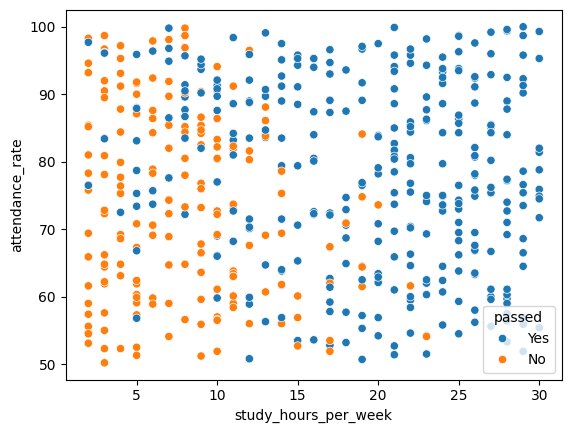

In [5]:
sns.scatterplot( x=df['study_hours_per_week'], y=df['attendance_rate'], hue=df['passed'])

In [6]:
x = df.iloc[:,0:2]
y = df.iloc[:,-1]

In [7]:
from sklearn.preprocessing import LabelEncoder,OneHotEncoder
le = LabelEncoder()
oe = OneHotEncoder()
y_encoded = le.fit_transform(y)
x_encoded = oe.fit_transform(x)

In [8]:
from sklearn.linear_model import Perceptron

In [9]:
p = Perceptron()

In [10]:
p.fit(x,y_encoded)

,"penalty penalty: {'l2','l1','elasticnet'}, default=NoneThe penalty (aka regularization term) to be used.",None
,"alpha alpha: float, default=0.0001Constant that multiplies the regularization term if regularization isused.",0.0001
,"l1_ratio l1_ratio: float, default=0.15The Elastic Net mixing parameter, with `0 <= l1_ratio <= 1`.`l1_ratio=0` corresponds to L2 penalty, `l1_ratio=1` to L1.Only used if `penalty='elasticnet'`... versionadded:: 0.24",0.15
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If False, thedata is assumed to be already centered.",True
,"max_iter max_iter: int, default=1000The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the ``fit`` method, and not the:meth:`partial_fit` method... versionadded:: 0.19",1000
,"tol tol: float or None, default=1e-3The stopping criterion. If it is not None, the iterations will stopwhen (loss > previous_loss - tol)... versionadded:: 0.19",0.001
,"shuffle shuffle: bool, default=TrueWhether or not the training data should be shuffled after each epoch.",True
,"verbose verbose: int, default=0The verbosity level.",0
,"eta0 eta0: float, default=1Constant by which the updates are multiplied.",1.0
,"n_jobs n_jobs: int, default=NoneThe number of CPUs to use to do the OVA (One Versus All, formulti-class problems) computation.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"random_state random_state: int, RandomState instance or None, default=0Used to shuffle the training data, when ``shuffle`` is set to``True``. Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary `.",0


In [11]:
p.coef_

array([[435. , -38.2]])

In [12]:
p.intercept_

array([-203.])

In [13]:
from mlxtend.plotting import plot_decision_regions


/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but Perceptron was fitted with feature names
  warnings.warn(


<Axes: >

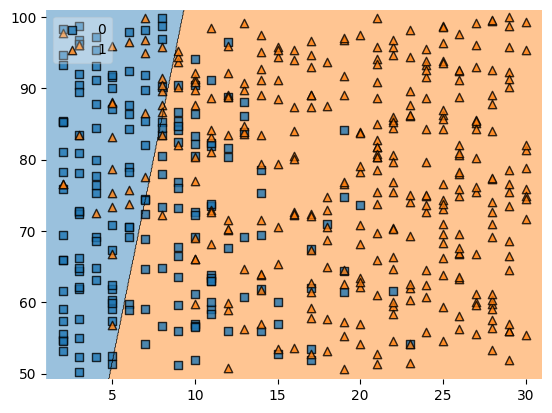

In [14]:
plot_decision_regions(x.values,y_encoded,clf=p,legend=2)

/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but Perceptron was fitted with feature names
  warnings.warn(


array([0])